In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Using device: cuda

Loading FOOD dataset...
Food Train samples: 2538
Food Val samples:   261

Loading FRUIT dataset...
Fruit Train samples: 1759
Fruit Val samples:   150

Combined Dataset Info:
Train samples total: 4297
Val samples total:   411

Dataloaders created successfully
Train batches: 135
Val batches:   13
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]



Model loaded and moved to device

Starting training...


Epoch 1/8


100%|██████████| 13/13 [01:55<00:00,  8.89s/it]


 Train Loss: 0.0013  Acc: 98.49%  Time: 1176.75s
 Val   Loss: 0.0053  Acc: 100.00%  Time: 115.64s

Epoch 2/8


...

 Train Loss: 0.0001  Acc: 99.93%  Time: 52.97s
 Val   Loss: 0.0004  Acc: 100.00%  Time: 3.86s

Epoch 7/8


100%|██████████| 13/13 [00:04<00:00,  2.69it/s]


 Train Loss: 0.0001  Acc: 99.91%  Time: 52.56s
 Val   Loss: 0.0012  Acc: 100.00%  Time: 4.83s

Epoch 8/8


100%|██████████| 13/13 [00:03<00:00,  3.27it/s]


 Train Loss: 0.0000  Acc: 100.00%  Time: 52.52s
 Val   Loss: 0.0004  Acc: 100.00%  Time: 3.98s

Total Training Time: 1688.29s

Training finished successfully


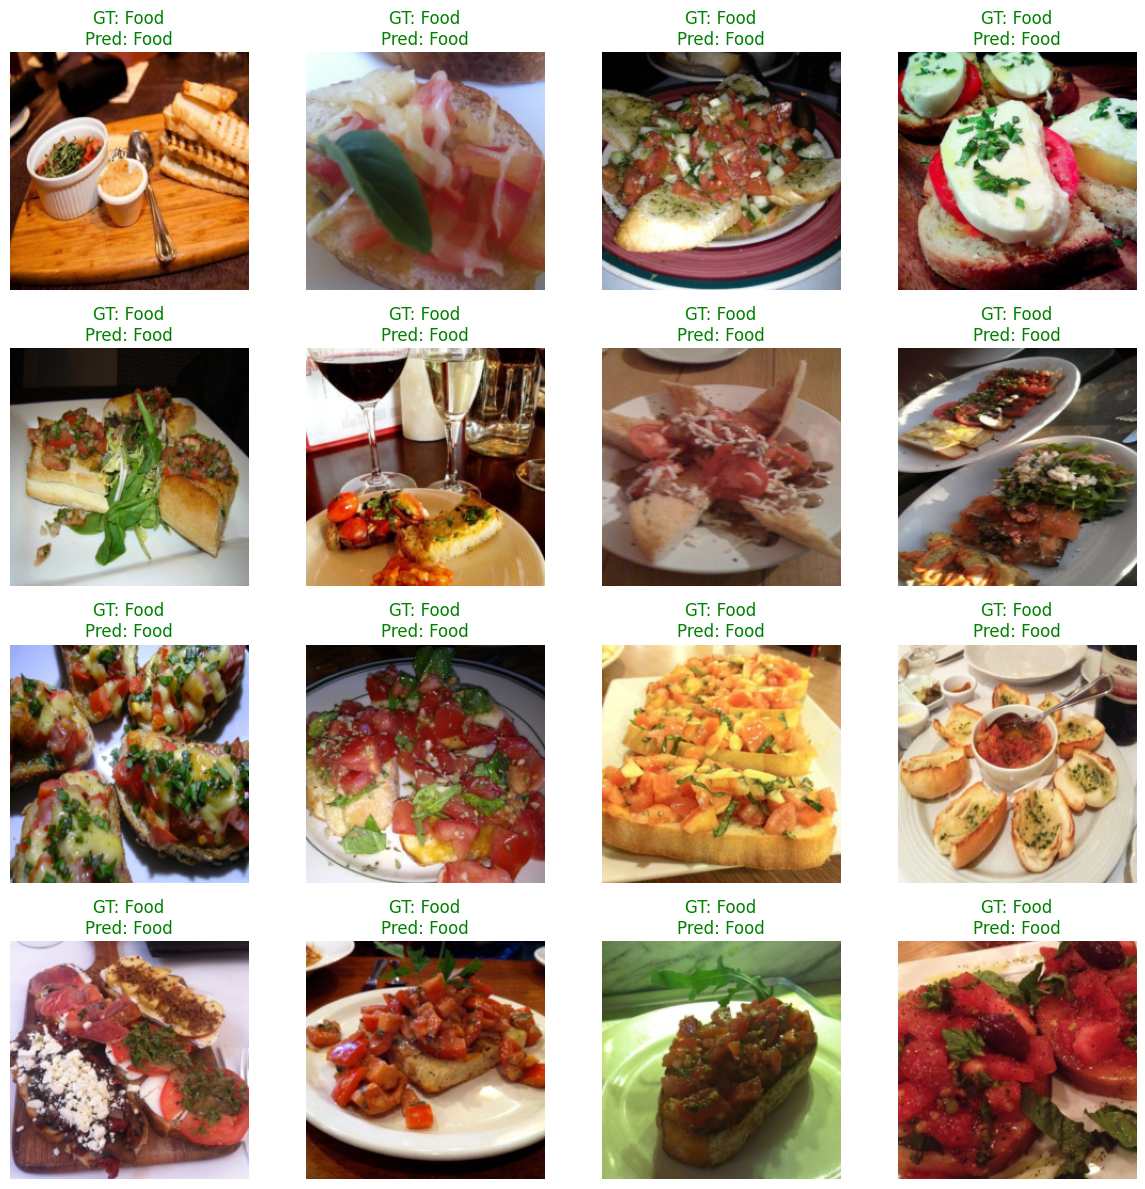


Model saved: FoodVsFruit_StageA.pth
Visualization saved: validation_classification_visualization.png


In [2]:
import os
import glob
import time
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models, datasets
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

print("\nLoading FOOD dataset...")
food_train = datasets.ImageFolder(
    r"/content/drive/MyDrive/Project Data/Food/Train",
    transform=transform
)
food_val = datasets.ImageFolder(
    r"/content/drive/MyDrive/Project Data/Food/Validation",
    transform=transform
)
print(f"Food Train samples: {len(food_train)}")
print(f"Food Val samples:   {len(food_val)}")

class FruitDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples = []
        if os.path.exists(root):
            classes = os.listdir(root)
            for cls in classes:
                img_folder = os.path.join(root, cls, "Images")
                if os.path.isdir(img_folder):
                    img_paths = glob.glob(img_folder + "/*")
                    for path in img_paths:
                        self.samples.append((path, 1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

print("\nLoading FRUIT dataset...")
fruit_train = FruitDataset(
    r"/content/drive/MyDrive/Project Data/Fruit/Train",
    transform=transform
)
fruit_val = FruitDataset(
    r"/content/drive/MyDrive/Project Data/Fruit/Validation",
    transform=transform
)
print(f"Fruit Train samples: {len(fruit_train)}")
print(f"Fruit Val samples:   {len(fruit_val)}")

class CombinedDataset(Dataset):
    def __init__(self, food_dataset, fruit_dataset):
        self.food_dataset = food_dataset
        self.fruit_dataset = fruit_dataset
        self.food_len = len(food_dataset)
        self.fruit_len = len(fruit_dataset)

    def __len__(self):
        return self.food_len + self.fruit_len

    def __getitem__(self, idx):
        if idx < self.food_len:
            img, _ = self.food_dataset[idx]
            return img, 0
        else:
            rel_idx = idx - self.food_len
            img, _ = self.fruit_dataset[rel_idx]
            return img, 1

train_dataset = CombinedDataset(food_train, fruit_train)
val_dataset = CombinedDataset(food_val, fruit_val)

print("\nCombined Dataset Info:")
print(f"Train samples total: {len(train_dataset)}")
print(f"Val samples total:   {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("\nDataloaders created successfully")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)
print("\nModel loaded and moved to device")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("\nStarting training...\n")

EPOCHS = 8
total_start = time.time()
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    t0 = time.time()
    model.train()
    total_correct = 0
    total_loss = 0

    for imgs, labels in tqdm(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_correct += (preds.argmax(1) == labels).sum().item()

    train_time = time.time() - t0
    train_acc = total_correct / len(train_dataset)
    train_loss = total_loss / len(train_dataset)

    t1 = time.time()
    model.eval()
    val_correct = 0
    val_loss = 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader):
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss = criterion(preds, labels)
            val_loss += loss.item() * imgs.size(0)
            val_correct += (preds.argmax(1) == labels).sum().item()

    val_time = time.time() - t1
    val_acc = val_correct / len(val_dataset)
    val_loss /= len(val_dataset)

    print(f" Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%  Time: {train_time:.2f}s")
    print(f" Val   Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%  Time: {val_time:.2f}s")
total_end = time.time()
total_duration = total_end - total_start
print(f"\nTotal Training Time: {total_duration:.2f}s")
print("\nTraining finished successfully")

model.eval()
images_shown = 0
max_images = 16

plt.figure(figsize=(12, 12))

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        preds = model(imgs).argmax(1)

        for i in range(len(imgs)):
            if images_shown >= max_images:
                break

            img = imgs[i].cpu().permute(1, 2, 0)
            gt = "Food" if labels[i].item() == 0 else "Fruit"
            pr = "Food" if preds[i].item() == 0 else "Fruit"
            color = "green" if gt == pr else "red"

            plt.subplot(4, 4, images_shown + 1)
            plt.imshow(img)
            plt.title(f"GT: {gt}\nPred: {pr}", color=color)
            plt.axis("off")

            images_shown += 1

        if images_shown >= max_images:
            break

plt.tight_layout()
plt.savefig("validation_classification_visualization.png", dpi=200)
plt.show()

torch.save(model.state_dict(), "FoodVsFruit_StageA.pth")
print("\nModel saved: FoodVsFruit_StageA.pth")
print("Visualization saved: validation_classification_visualization.png")